# PPDS PROJECT

**Note**: This project is done in the Jupyter Notebook.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Overview

**Data Loading**

In [9]:
data = pd.read_csv("austo_automobile .csv")

**Creating a copy of the data**

In [11]:
df = data.copy()

**Data Overview**

In [13]:
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


In [14]:
print("The number of rows in data:", df.shape[0], "\nThe number of columns in data:", df.shape[1])

The number of rows in data: 1581 
The number of columns in data: 14


**Dataframe Information**

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


**Duplicate Rows**

In [18]:
df.duplicated().sum()

0

There are no duplicated rows in the dataset.

**Gender Distribution**

In [21]:
df['Gender'].value_counts()

Gender
Male      1199
Female     327
Femal        1
Femle        1
Name: count, dtype: int64

**Marital Status**

In [23]:
df['Marital_status'].value_counts()

Marital_status
Married    1443
Single      138
Name: count, dtype: int64

**Profession**

In [25]:
df['Profession'].value_counts()

Profession
Salaried    896
Business    685
Name: count, dtype: int64

**Education**

In [27]:
df['Education'].value_counts()

Education
Post Graduate    985
Graduate         596
Name: count, dtype: int64

**Loans**

In [29]:
df['House_loan'].value_counts()

House_loan
No     1054
Yes     527
Name: count, dtype: int64

In [30]:
df['Personal_loan'].value_counts()

Personal_loan
Yes    792
No     789
Name: count, dtype: int64

**Partner Working**

In [32]:
df['Partner_working'].value_counts()

Partner_working
Yes    868
No     713
Name: count, dtype: int64

**Vehicle Make**

In [34]:
df['Make'].value_counts()

Make
Sedan        702
Hatchback    582
SUV          297
Name: count, dtype: int64

# Handling Missing Values

In [36]:
df['Gender'].isnull().value_counts()

Gender
False    1528
True       53
Name: count, dtype: int64

- Checked for missing values in the 'Gender' column.
- The percentage and count of missing values for each column were printed.

In [38]:
print("Missing values count and percentage:")

pd.DataFrame(
    {
        "Count": df.isnull().sum()[df.isnull().sum() > 0],
        "Percentage": (df.isnull().sum()[df.isnull().sum() > 0])/ df.shape[0]*100
    }
)

Missing values count and percentage:


,Count,Percentage
Gender,53,3.352309
Partner_salary,106,6.704617


- Checking for missing values in the 'Partner_salary' column.

In [40]:
df.loc[df['Partner_salary'].isnull() == True]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
40,53,Female,Salaried,Married,Graduate,1,Yes,No,No,72100,NaN,72100,60000,SUV
43,52,Male,Salaried,Married,Post Graduate,3,No,No,Yes,87600,NaN,88200,51000,SUV
49,52,Female,Business,Married,Post Graduate,4,No,No,Yes,90300,NaN,170400,69000,SUV
59,54,Male,Salaried,Married,Graduate,3,Yes,No,Yes,80600,NaN,81000,51000,SUV
111,48,Female,Business,Married,Graduate,3,No,No,Yes,90300,NaN,161100,62000,SUV
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1559,22,Male,Business,Married,Post Graduate,3,Yes,No,No,52100,NaN,52100,28000,Hatchback
1567,22,Male,Salaried,Single,Graduate,0,Yes,Yes,No,39700,NaN,39700,23000,Hatchback
1568,22,Male,Salaried,Married,Graduate,3,No,Yes,No,38000,NaN,38000,23000,Sedan
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback


- Filling missing values in the 'Partner_salary' column with 0 and converting the column to integer type.

In [42]:
df['Partner_salary'] = df['Partner_salary'].fillna(value= 0)

In [43]:
df['Partner_salary'] = df['Partner_salary'].astype(int)
df.dtypes

Age                  int64
Gender              object
Profession          object
Marital_status      object
Education           object
No_of_Dependents     int64
Personal_loan       object
House_loan          object
Partner_working     object
Salary               int64
Partner_salary       int32
Total_salary         int64
Price                int64
Make                object
dtype: object

- Displaying rows where 'Partner_working' is 'Yes' and 'Partner_salary' is 0.

In [45]:
df.loc[(df['Partner_working'] == 'Yes') & (df['Partner_salary'] == 0), 'Partner_salary']

43      0
49      0
59      0
111     0
209     0
284     0
339     0
376     0
424     0
444     0
554     0
654     0
779     0
1345    0
1349    0
1546    0
Name: Partner_salary, dtype: int32

- Updating the column 'Partner_salary' where 'Partner_working' is 'Yes' and 'Partner_salary' is 0.
- Once the missing values in 'Partner_salary' were filled in, the count and percentage of missing values were printed.

In [47]:
df.loc[(df['Partner_working'] == 'Yes') & (df['Partner_salary'] == 0), 'Partner_salary'] = df['Total_salary'] - df['Salary']

C:\Users\91824\AppData\Local\Temp\ipykernel_12756\3787414069.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[  600 80100   400 70800 70500 35300 38600 38400 38700 40100 28500 28500
 28700 24200 25800 26700]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  df.loc[(df['Partner_working'] == 'Yes') & (df['Partner_salary'] == 0), 'Partner_salary'] = df['Total_salary'] - df['Salary']


In [48]:
print("Missing values count and percentage:")

pd.DataFrame(
    {
        "Count": df.isnull().sum()[df.isnull().sum() > 0],
        "Percentage": (df.isnull().sum()[df.isnull().sum() > 0])/ df.shape[0]*100
    }
)

Missing values count and percentage:


,Count,Percentage
Gender,53,3.352309


**Treating Gender Column**

In [50]:
df.loc[df['Gender'].isnull() == True]

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
24,46,NaN,Business,Married,Post Graduate,3,Yes,No,Yes,78000,600,78600,50000,SUV
25,46,NaN,Salaried,Married,Post Graduate,3,No,No,Yes,87900,700,88600,50000,SUV
67,53,NaN,Salaried,Married,Graduate,4,Yes,No,Yes,80900,30000,110900,49000,SUV
125,47,NaN,Salaried,Single,Post Graduate,2,Yes,No,No,87200,0,87200,49000,SUV
203,44,NaN,Salaried,Single,Post Graduate,0,Yes,No,No,68600,0,68600,50000,SUV
302,41,NaN,Salaried,Married,Graduate,1,Yes,No,No,55900,0,55900,32000,Sedan
325,40,NaN,Business,Married,Graduate,1,No,Yes,No,59600,0,59600,31000,Sedan
463,36,NaN,Salaried,Married,Post Graduate,3,Yes,No,No,66600,0,66600,49000,SUV
485,35,NaN,Business,Married,Post Graduate,2,Yes,Yes,Yes,61600,25000,86600,31000,Sedan
528,34,NaN,Salaried,Single,Post Graduate,2,No,Yes,No,64800,0,64800,32000,Sedan


- Filling the missing values in the 'Gender' column with the mode value.
- Once the missing values in 'Gender' were filled in, the count and percentage of missing values were printed.

In [52]:
df['Gender'].mode()[0]

'Male'

In [53]:
df['Gender'] = df['Gender'].fillna(value= df['Gender'].mode()[0])

In [54]:
print("Missing values count and percentage:")

pd.DataFrame(
    {
        "Count": df.isnull().sum()[df.isnull().sum() > 0],
        "Percentage": (df.isnull().sum()[df.isnull().sum() > 0])/ df.shape[0]*100
    }
)

Missing values count and percentage:


,Count,Percentage


**Correcting Misspelled Values:**

- Correcting the misspelled values in the 'Gender' column ('Femal' and 'Femle' to 'Female').
- After correction, the value counts for "Gender" were printed.

In [56]:
df['Gender'].value_counts()

Gender
Male      1252
Female     327
Femal        1
Femle        1
Name: count, dtype: int64

In [57]:
df.loc[df['Gender'] == 'Femal', 'Gender']

1    Femal
Name: Gender, dtype: object

In [58]:
df.loc[df['Gender'] == 'Femle', 'Gender']

305    Femle
Name: Gender, dtype: object

In [59]:
df.loc[df['Gender'] == 'Femal', 'Gender'] = 'Female'
df.loc[df['Gender'] == 'Femle', 'Gender'] = 'Female'

In [60]:
df['Gender'].value_counts()

Gender
Male      1252
Female     329
Name: count, dtype: int64

In [61]:
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700,170000,61000,SUV
1,53,Female,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200,139900,57000,SUV


### Observation and Insights

1. **Data Overview**:

    - The dataset contains 1000 rows and 14 columns.
    - The columns include personal information, financial details, and vehicle-related data.

2. **Duplicate Rows**:

    There are no duplicated rows in the dataset.

3. **Gender Distribution**:

    - The 'Gender' column initially had some missing and misspelled values.
    - After correction, the distribution is as follows:
        Male: 1252
        Female: 329

4. **Marital Status**:

    The majority of individuals are married.

5. **Profession**:

    The dataset includes both salaried and business professionals.

6. **Education**:

    A significant number of individuals are postgraduates.

7. **Loans**:

    The dataset includes information on personal loans and house loans.

8. **Partner Working and Salary**:

    Some individuals have partners who are working, and their partner's salary was initially missing but has been filled and corrected.

9. **Vehicle Make**:

    The dataset includes various vehicle makes, with a focus on SUVs and sedans.

10. **Missing Values**:

    Missing values were handled appropriately by filling with mode or calculated values.

# Univariate Analysis

In [64]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1581.0,19233.776091,19670.391171,0.0,0.0,25100.0,38100.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


## **Numerical Analysis**

### **Age Distribution**

**Histogram**: Shows a normal distribution with a peak around the age of 30.

**Boxplot**: Indicates more number of people are between the ages of 25 and 30.

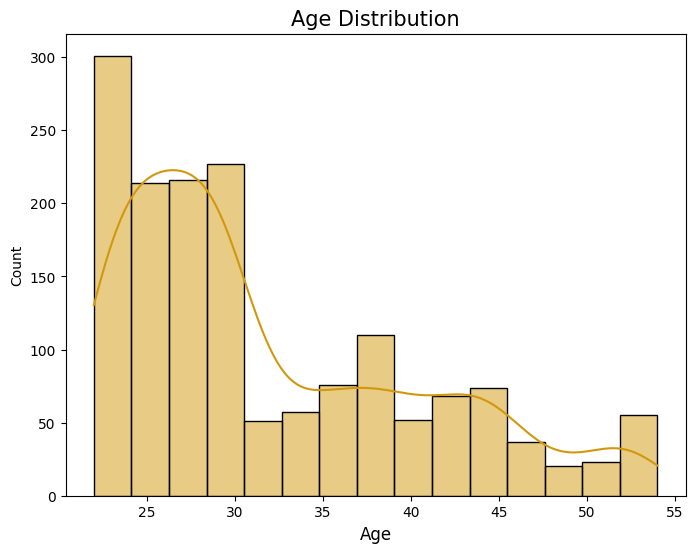

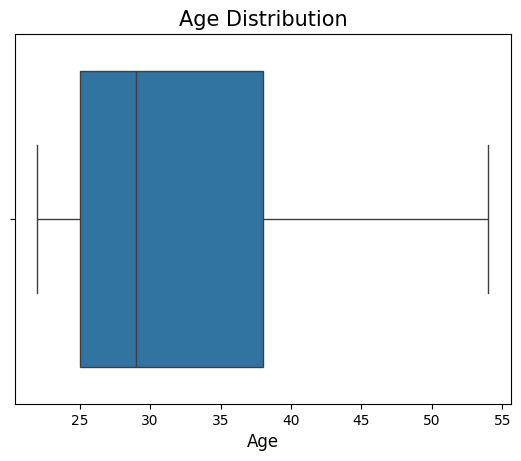

In [67]:
plt.figure(figsize=(8,6))
sns.histplot(data= df, x= 'Age', kde= True, color= '#d2980d')
plt.title("Age Distribution", fontsize= 15)
plt.xlabel('Age', fontsize=12)
plt.show()
sns.boxplot(data= df, x= 'Age')
plt.title("Age Distribution", fontsize= 15)
plt.xlabel('Age', fontsize=12)
plt.show()

### **Total Salary Distribution**

**Histogram**: Displays a right-skewed distribution, indicating a higher number of individuals with lower total salaries.

**Boxplot**: Indicates some high earners as outliers.

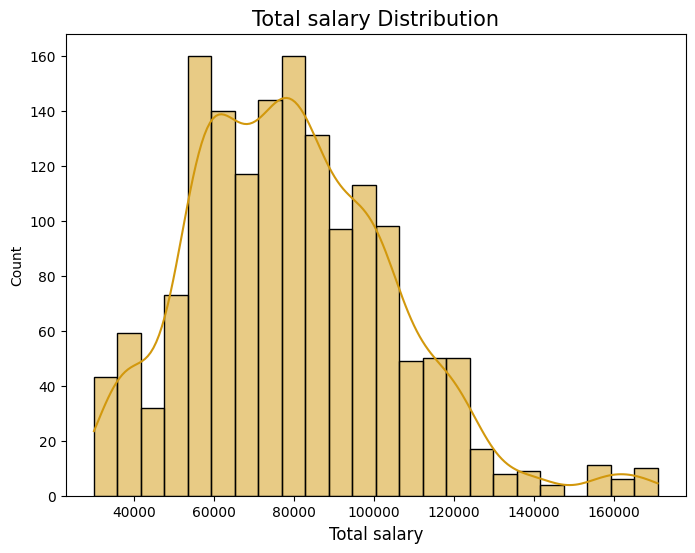

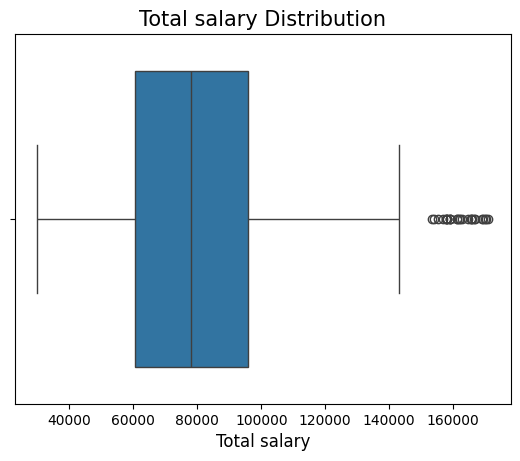

In [69]:
plt.figure(figsize=(8,6))
sns.histplot(data= df, x= 'Total_salary', kde= True, color= "#D2980D") # This color is golden yellow
plt.title("Total salary Distribution", fontsize= 15)
plt.xlabel('Total salary', fontsize=12)
plt.show()
sns.boxplot(data= df, x='Total_salary')
plt.title("Total salary Distribution", fontsize= 15)
plt.xlabel('Total salary', fontsize=12)
plt.show()

### **Number of Dependents Distribution**

**Histogram**: The majority of people have two or three dependents.

**Boxplot**: Few outliers, indicating some individuals with no dependents.

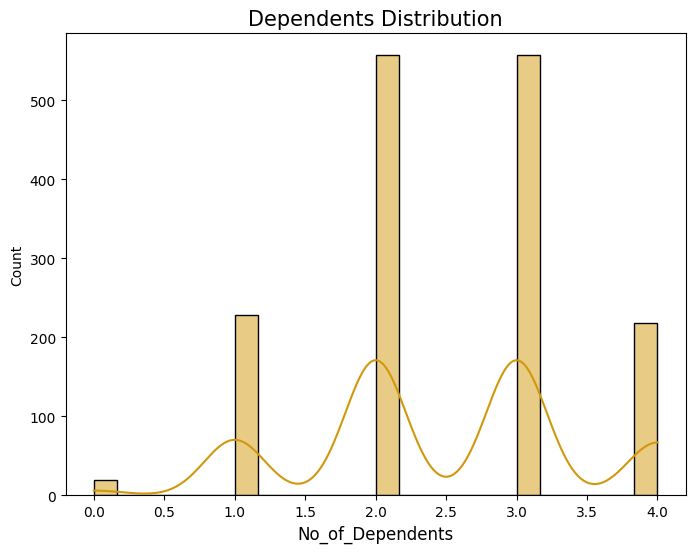

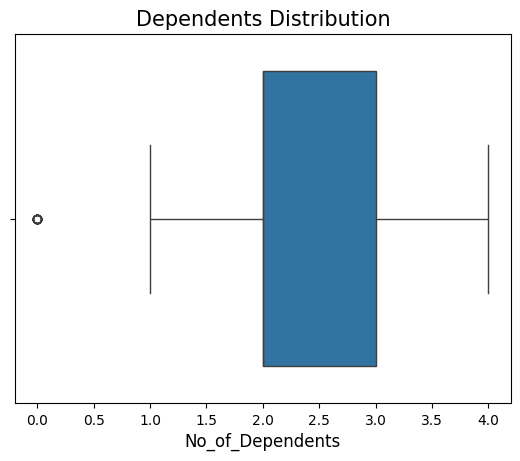

In [71]:
plt.figure(figsize=(8,6))
sns.histplot(data= df, x= 'No_of_Dependents', kde= True, color= "#d2980d")
plt.title("Dependents Distribution", fontsize= 15)
plt.xlabel("No_of_Dependents", fontsize= 12)
plt.show()
sns.boxplot(data= df, x= 'No_of_Dependents')
plt.title("Dependents Distribution", fontsize= 15)
plt.xlabel("No_of_Dependents", fontsize= 12)
plt.show()

## **Categorical Analysis**

### **Education**

**Countplot**: The majority of individuals have a postgraduate degree.

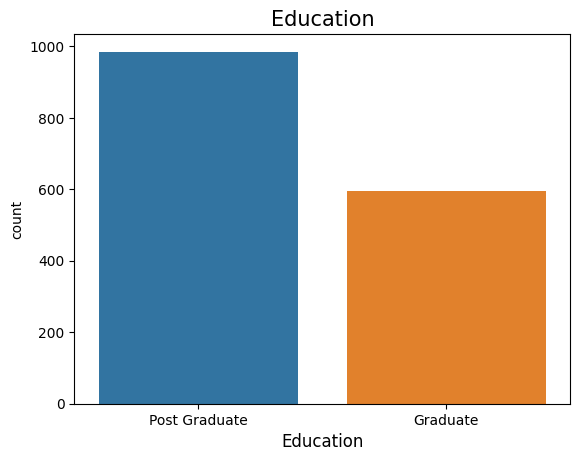

In [74]:
sns.countplot(x='Education', data=df, hue='Education')
plt.title('Education', fontsize=15) 
plt.xlabel('Education',fontsize=12)
plt.show()

### **Vehicle Make**

**Countplot**: Sedan is the most common vehicle make.

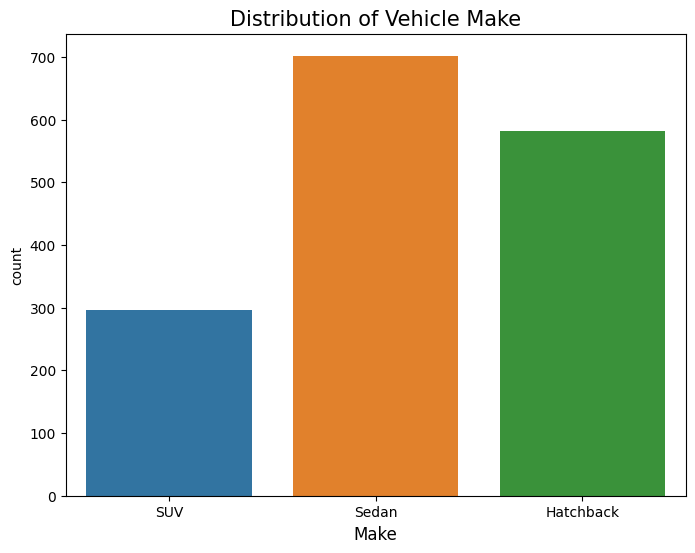

In [76]:
plt.figure(figsize=(8,6))
sns.countplot(data= df, x='Make',hue='Make')
plt.title('Distribution of Vehicle Make', fontsize= 15)
plt.xlabel('Make', fontsize=12)
plt.savefig('Distribution of Vehicle Make.png')
plt.show()

### **Personal Loan Distribution**

**Countplot**: Shows the distribution of personal loans across different age groups.

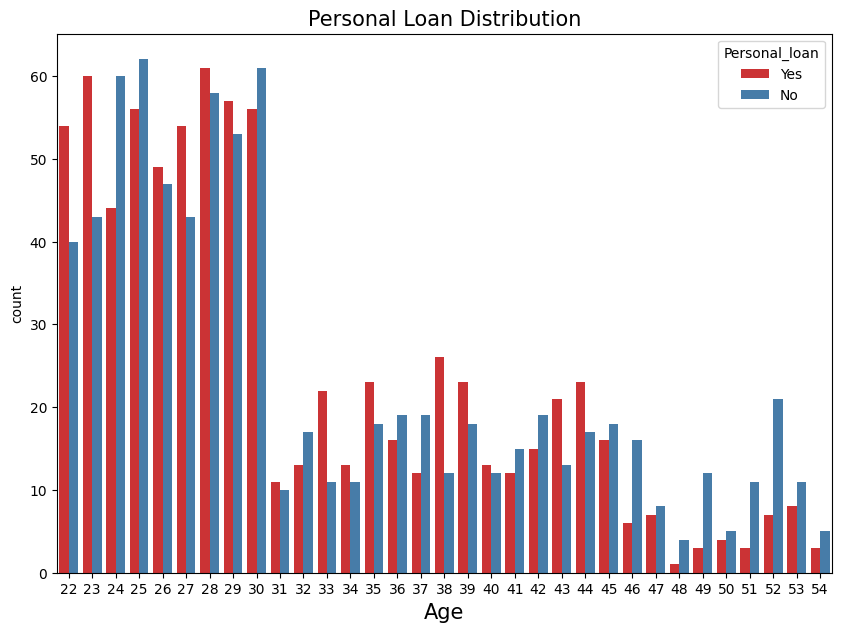

In [78]:
plt.figure(figsize=(10,7))
sns.countplot(data= df, x= 'Age', hue='Personal_loan', palette='Set1')
plt.title("Personal Loan Distribution", fontsize= 15)
plt.xlabel("Age", fontsize= 15)
plt.show()

### **Salary Distribution**

**Distplot**: Shows a normal distribution with a peak around ₹60,000.

<Figure size 800x600 with 0 Axes>

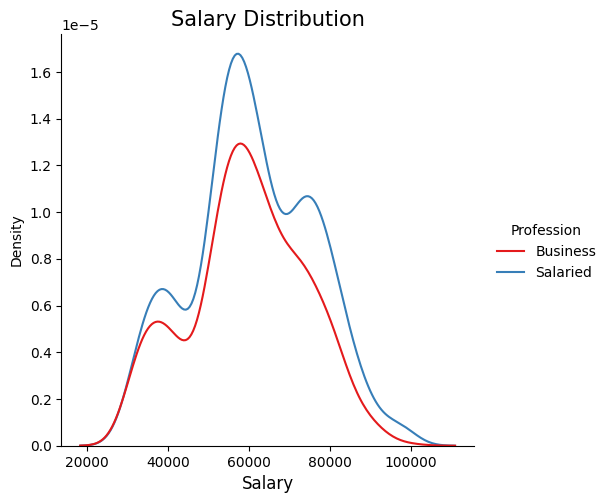

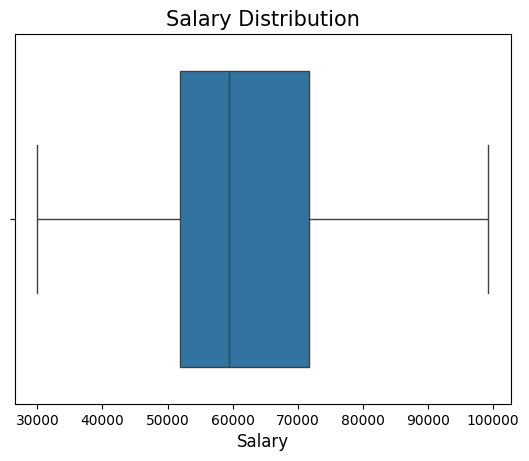

In [80]:
plt.figure(figsize=(8,6))
sns.displot(data= df, x= 'Salary', hue='Profession',kind='kde', palette='Set1')
plt.title("Salary Distribution", fontsize= 15)
plt.xlabel("Salary", fontsize= 12)
plt.show()
sns.boxplot(data= df, x= 'Salary')
plt.title("Salary Distribution", fontsize= 15)
plt.xlabel("Salary", fontsize= 12)
plt.show()

### **Price Distribution**

**Distplot**: Displays a right-skewed distribution, with most vehicles priced between ₹20,000 and ₹40,000.

<Figure size 800x600 with 0 Axes>

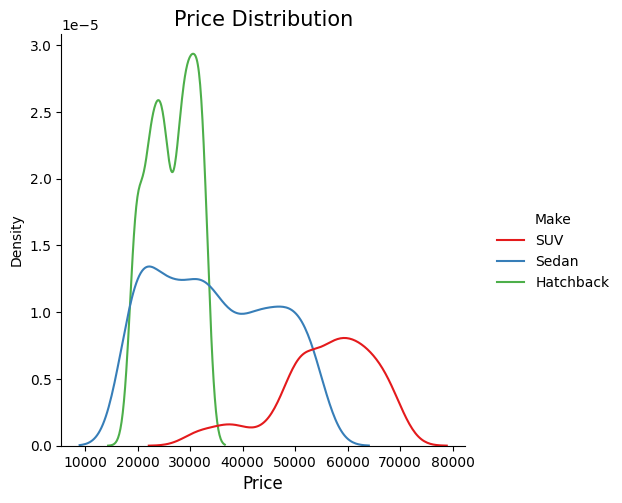

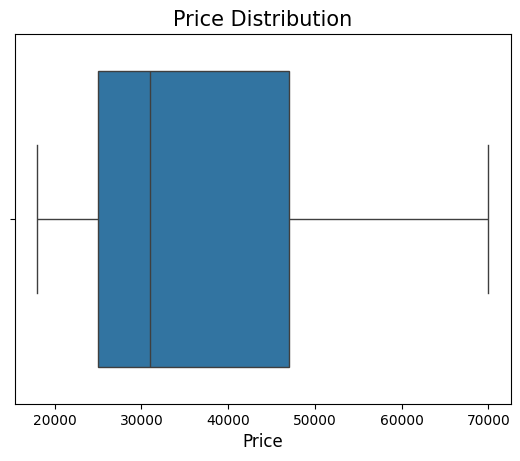

In [82]:
plt.figure(figsize=(8,6))
sns.displot(data= df, x= 'Price', hue='Make', kind= 'kde', palette='Set1')
plt.title("Price Distribution", fontsize= 15)
plt.xlabel("Price", fontsize= 12)
plt.show()
sns.boxplot(data= df, x= 'Price')
plt.xlabel("Price", fontsize= 12)
plt.title("Price Distribution", fontsize= 15)
plt.xlabel("Price", fontsize= 12)
plt.savefig('Price Distribution.png')
plt.show()

# Handling Outliers

In [84]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1581.0,19233.776091,19670.391171,0.0,0.0,25100.0,38100.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


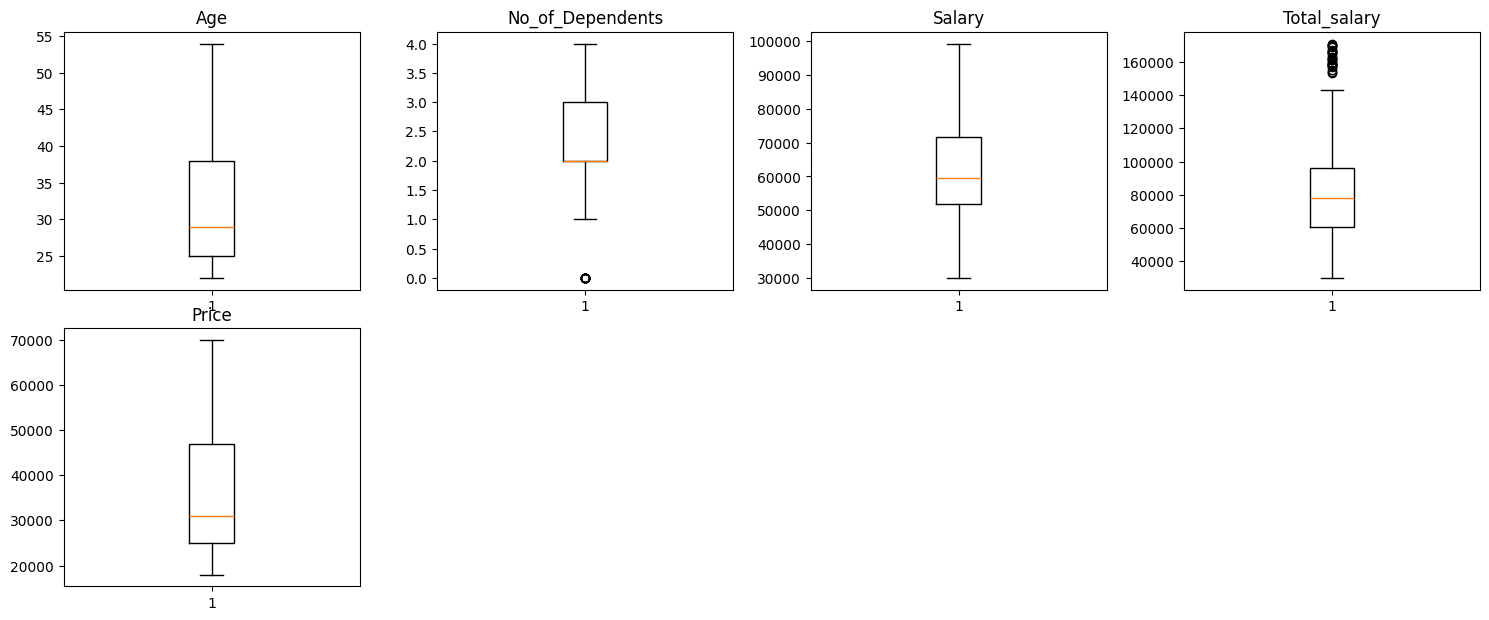

In [85]:
numeric_columns = [
    "Age",
    "No_of_Dependents",
    "Salary",
    "Total_salary",
    "Price"
]

plt.figure(figsize=[15,12])
for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i+1)
    plt.boxplot(data [variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

In [86]:
# Q1 = data[numeric_columns].quantile(0.25)
# Q3 = data[numeric_columns].quantile(0.75)
# IQR = Q3 - Q1

# low_whisker = Q1 - 1.5 * IQR
# high_whisker = Q3 + 1.5 * IQR

In [87]:
def treat_outliers(data, col):
     Q1 = data[col].quantile(0.25)
     Q3 = data[col].quantile(0.75)
     IQR = Q3 - Q1
    
     low_whisker = Q1 - 1.5 * IQR
     high_whisker = Q3 + 1.5 * IQR

     median = data[col].median()
     data[col] = data[col].apply(lambda x: median if x < low_whisker or x > high_whisker else x)
     return data

In [88]:
for column in numeric_columns:
    data = treat_outliers(data, column)

- The outliers have been effectively handled, with no extreme values outside the whiskers.
- The outliers at 0 dependents have been replaced with the median value.
- The high outliers in Total Salary have been replaced with the median, with fewer extreme values.

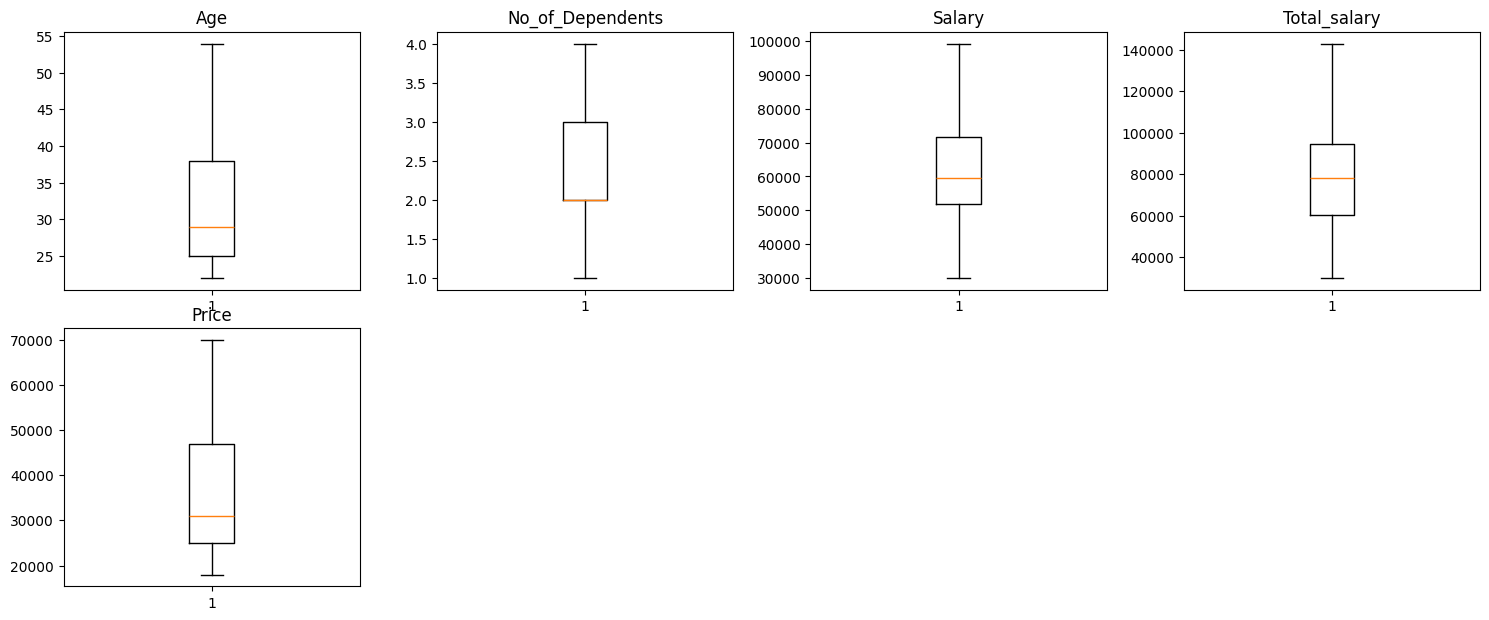

In [90]:
numeric_columns = [
    "Age",
    "No_of_Dependents",
    "Salary",
    "Total_salary",
    "Price"
]

plt.figure(figsize=[15,12])
for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i+1)
    plt.boxplot(data [variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

### **Insights:**

**High Earners**: The dataset includes a significant number of high earners.

**Vehicle Pricing**: Most vehicles are priced between ₹20,000 and ₹40,000.

**Dependents**: The majority of individuals have 2-3 dependents.

**Education and Profession**: A significant number of individuals are postgraduates and salaried professionals.

#### **Saving the Cleaned DataFrame into csv file**

In [93]:
df.to_csv('austo_automobile_new.csv', index= False)

# Bivariate Analysis

In [95]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1581.0,19233.776091,19670.391171,0.0,0.0,25100.0,38100.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


### **Relationship Between Age and Salary**

**Observation**: The scatter plot shows a positive correlation between age and salary. 

**Insight**: As age increases, salary tends to increase, likely due to career progression and accumulated experience.

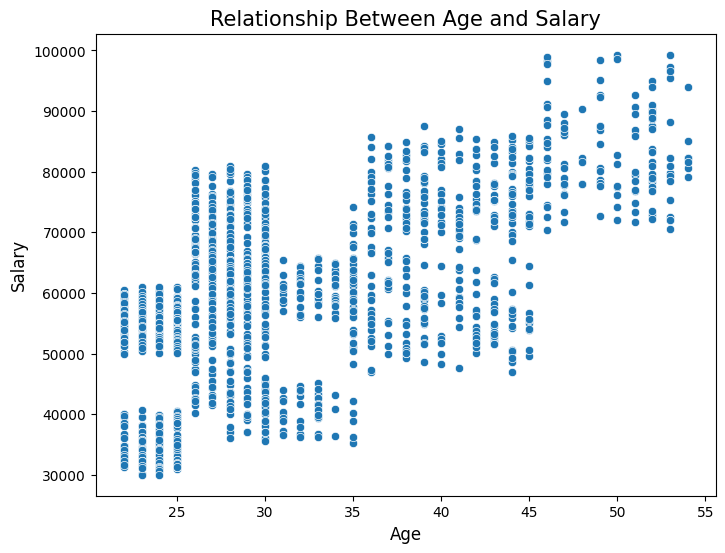

In [97]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x='Age', y= 'Salary')
plt.title('Relationship Between Age and Salary', fontsize= 15)
plt.xlabel('Age', fontsize= 12)
plt.ylabel('Salary', fontsize= 12)
plt.show()

### **Relationship Between Age and Total Salary**

**Observation**: The scatter plot indicates a positive correlation between age and total salary. 

**Insight**: Older individuals generally have higher total salaries due to their experience.


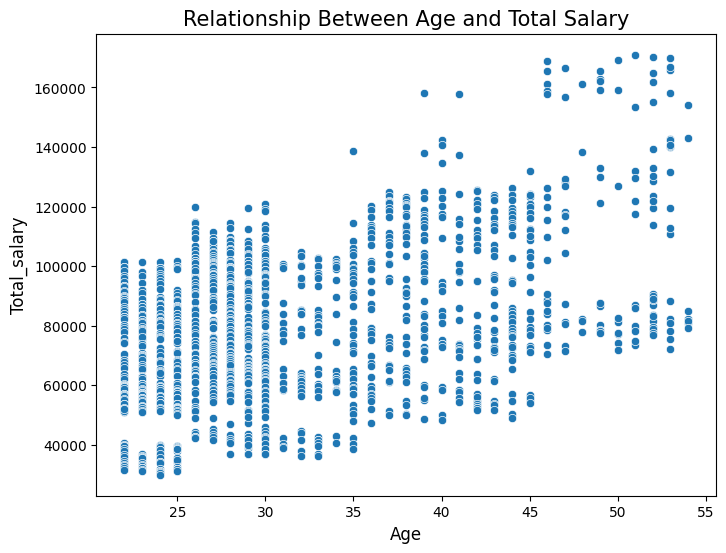

In [99]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x='Age', y= 'Total_salary')
plt.title('Relationship Between Age and Total Salary', fontsize= 15)
plt.xlabel('Age', fontsize= 12)
plt.ylabel('Total_salary', fontsize= 12)
plt.show()

### **Relationship Between Age and Price**

**Observation**: The Line plot shows that older individuals tend to purchase higher-priced vehicles. 

**Insight**: Older individuals might have higher income, allowing them to afford more expensive vehicles.

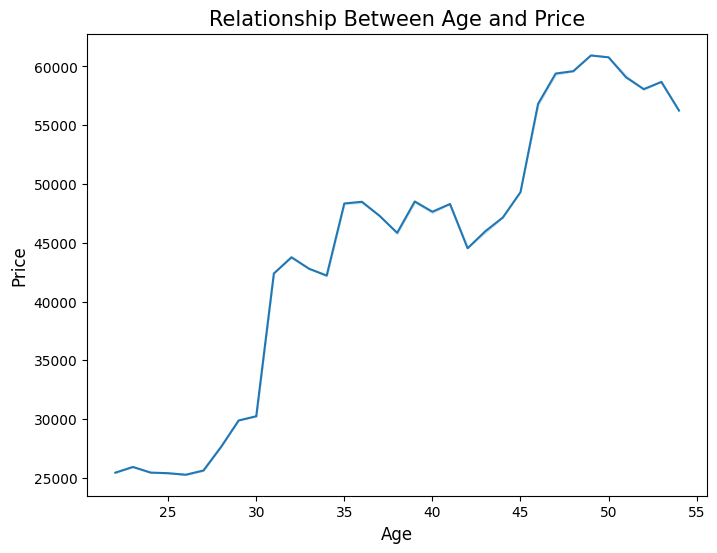

In [101]:
plt.figure(figsize=(8,6))
sns.lineplot(data= df, x='Age', y= 'Price', errorbar=('ci', False))
plt.title('Relationship Between Age and Price', fontsize= 15)
plt.xlabel('Age', fontsize= 12)
plt.ylabel('Price', fontsize= 12)
plt.show()

### **Relationship Between Salary and Price**

**Observation**: The Line plot reveals a positive correlation between salary and vehicle price. 

**Insight**: Higher salaries are associated with higher-priced vehicles, indicating that individuals with higher incomes tend to buy more expensive cars.

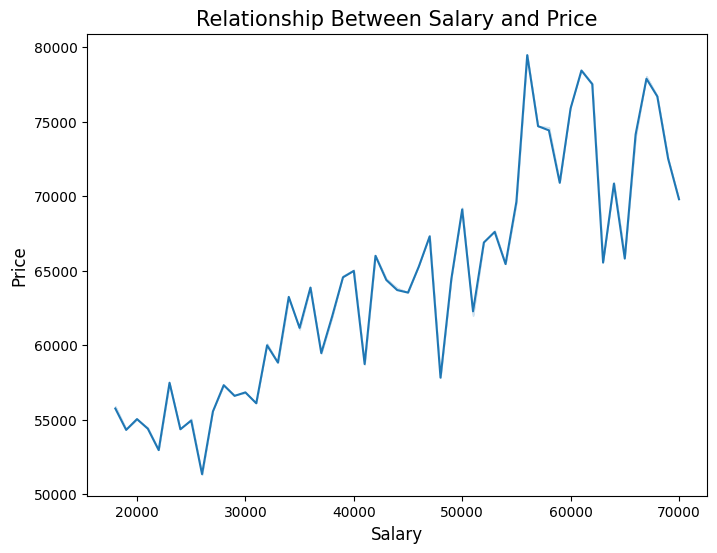

In [103]:
plt.figure(figsize=(8,6))
sns.lineplot(data= df, x='Price', y= 'Salary', errorbar=('ci', False))
plt.title('Relationship Between Salary and Price', fontsize=15)
plt.xlabel('Salary', fontsize= 12)
plt.ylabel('Price', fontsize= 12)
plt.show()

### **Relationship Between Total Salary and Price**

**Observation**: The scatter plot shows a positive correlation between total salary and vehicle price.

**Insight**: Higher total salaries are associated with higher-priced vehicles, suggesting that households with higher combined incomes tend to purchase more expensive cars.

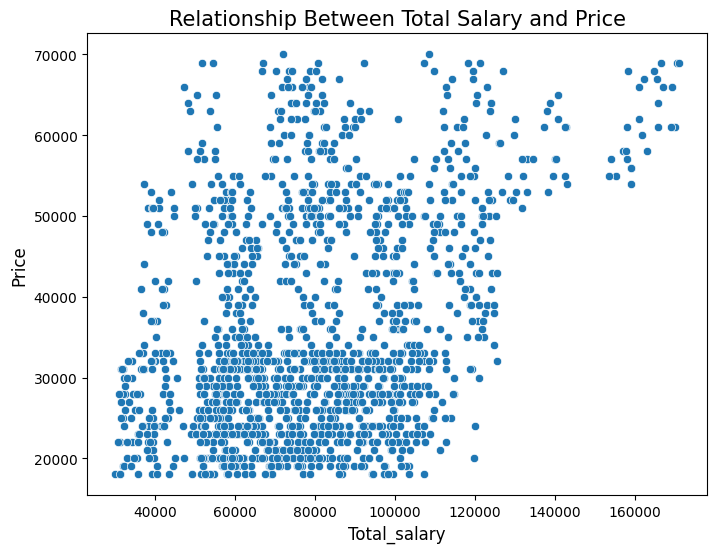

In [105]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x='Total_salary', y= 'Price')
plt.title('Relationship Between Total Salary and Price',fontsize= 15)
plt.xlabel('Total_salary', fontsize= 12)
plt.ylabel('Price', fontsize= 12)
plt.savefig('Relationship Between Total Salary and Price.png')
plt.show()

### **Observation on Make and Price**

**Observation**: The box plot shows the distribution of vehicle prices across different makes.

**Insight**: SUVs tend to be priced higher compared to other vehicle makes, indicating a preference for more expensive models in this category.

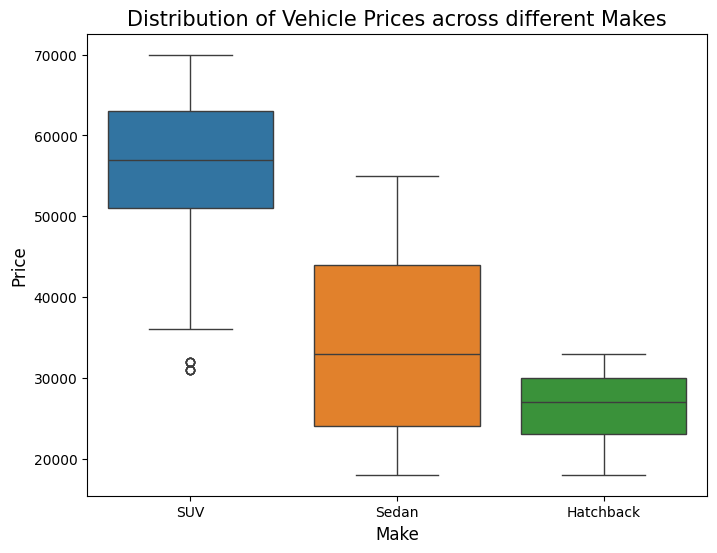

In [107]:
plt.figure(figsize=(8,6))
sns.boxplot(data= df, x='Make', y= 'Price', hue='Make')
plt.title('Distribution of Vehicle Prices across different Makes', fontsize=15)
plt.xlabel('Make', fontsize= 12)
plt.ylabel('Price', fontsize= 12)
plt.show()

## **Correlation**

**Observation**: The heat map highlights strong positive correlations between salary and total salary, and moderate positive correlations between total salary and partner salary, as well as between price and total salary.

**Insight**: These correlations suggest that household income components are closely related, and higher incomes are associated with higher vehicle prices.

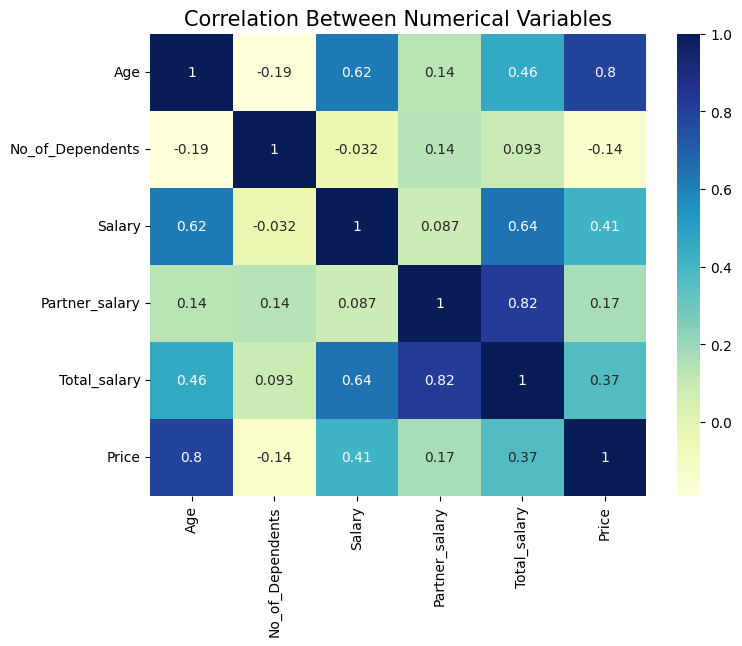

In [110]:
plt.figure(figsize=(8,6))
sns.heatmap(data= df[['Age','No_of_Dependents','Salary','Partner_salary','Total_salary','Price']].corr(),
            annot= True, cmap= 'YlGnBu')
plt.title('Correlation Between Numerical Variables',fontsize=15)
plt.show()

### **Pair Plot**

**Observation**: The pair plot visualizes the relationships between all pairs of numerical variables.

**Insight**: It helps identify patterns and correlations, such as the positive relationships between age and salary, and between salary and price.

<Figure size 800x600 with 0 Axes>

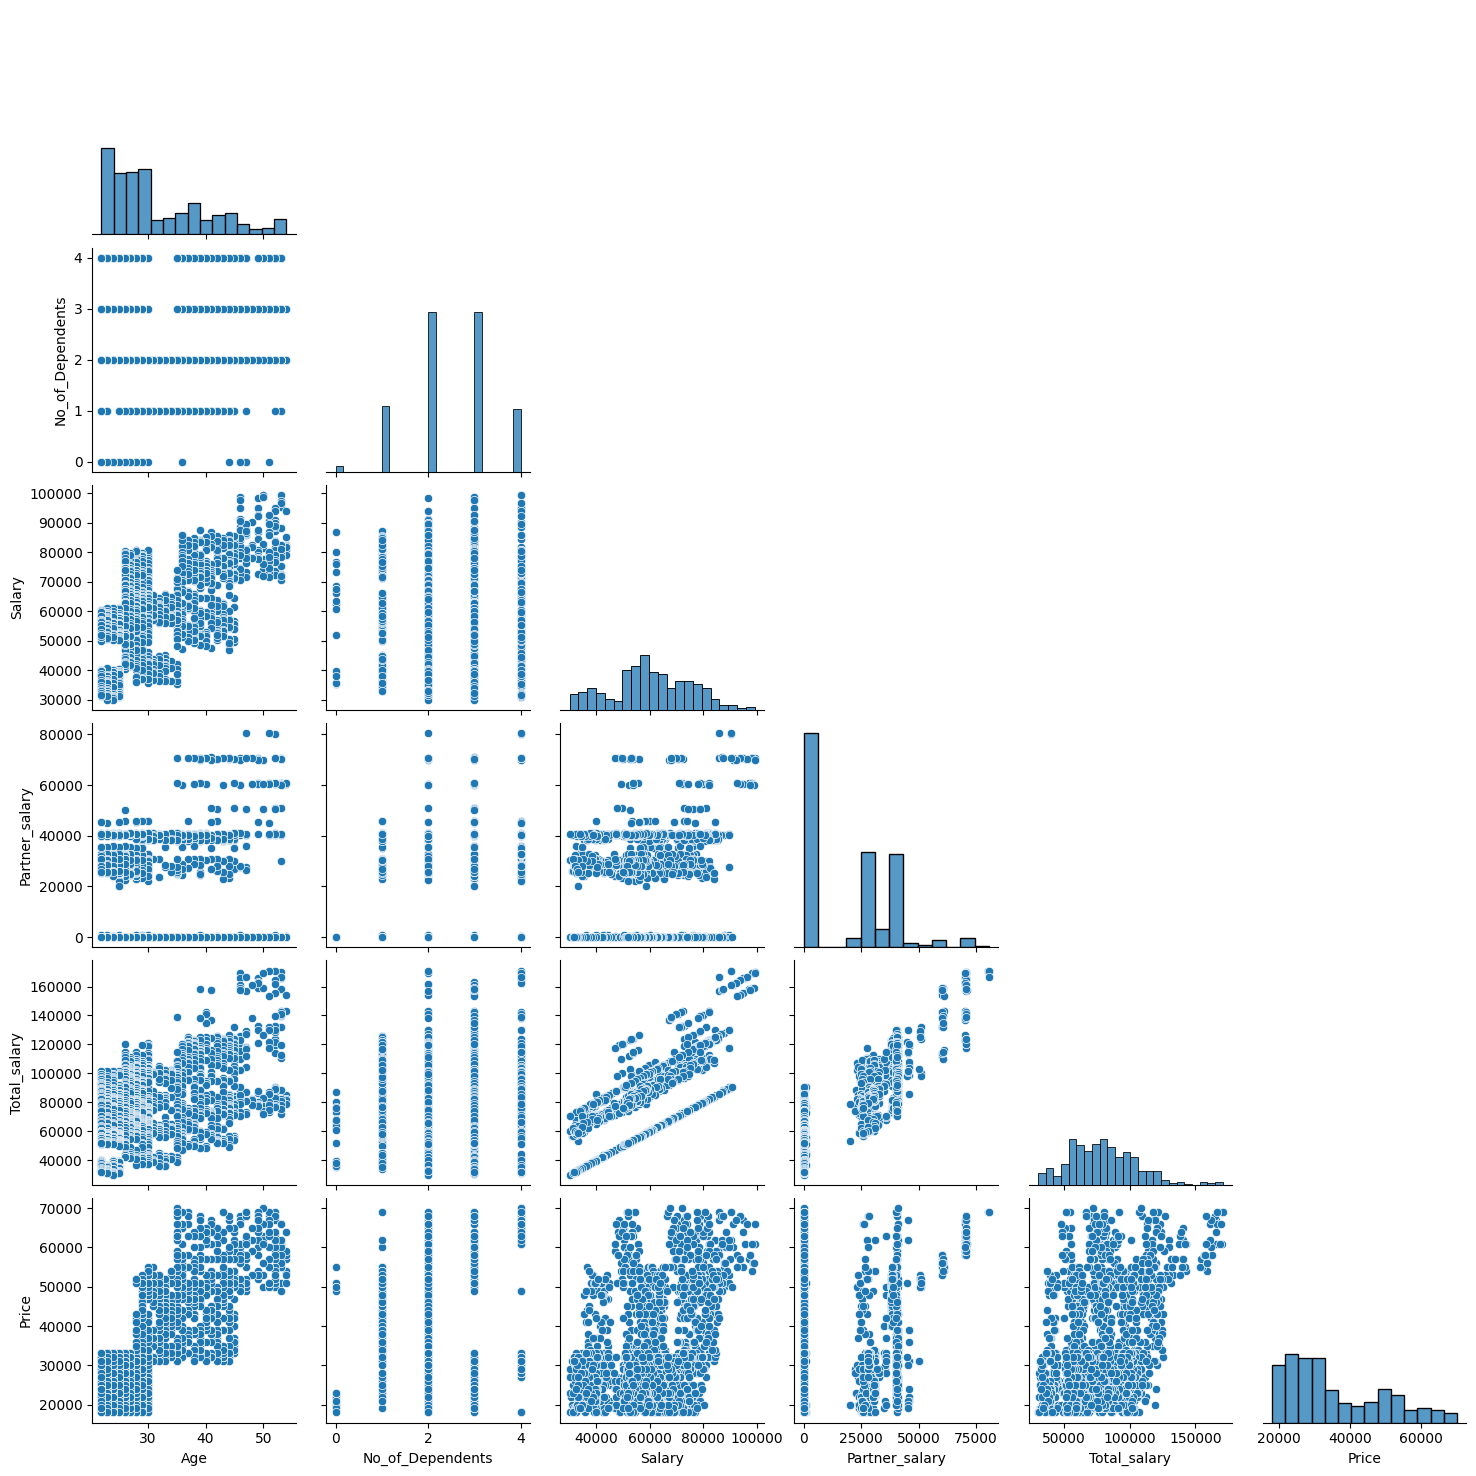

In [112]:
plt.figure(figsize=(8,6))
sns.pairplot(data= df[['Age','No_of_Dependents','Salary','Partner_salary','Total_salary','Price']],corner= True)
plt.show()

### **Age and Salary Distribution by Gender**

**Observation**: The line plot visualizes the relationship between age and salary, with lines differentiated by gender.

**Insight**: This plot reveals possible differences in salary trends between males and females as they age, highlighting gender-based differences in salary progression over time.

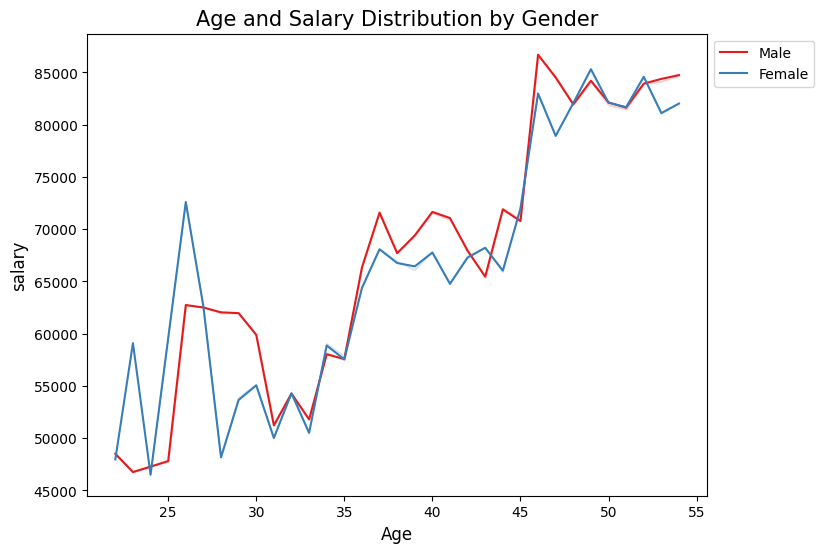

In [114]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df, x= 'Age', y= 'Salary', hue='Gender', errorbar=('ci', False), palette='Set1')
plt.title('Age and Salary Distribution by Gender', fontsize=15)
plt.xlabel('Age', fontsize= 12)
plt.ylabel('salary', fontsize= 12)
plt.legend(bbox_to_anchor=(1,1))
plt.savefig('Age and Salary Distribution by Gender.png')
plt.show()

### **Total Salary and Vehicle Price Distribution across Gender**

**Observation**: The scatter plot shows the relationship between total salary and vehicle price, differentiated by gender.

**Insight**: There may be gender-based differences in the relationship between total salary and vehicle price, with great variations in purchasing behavior.

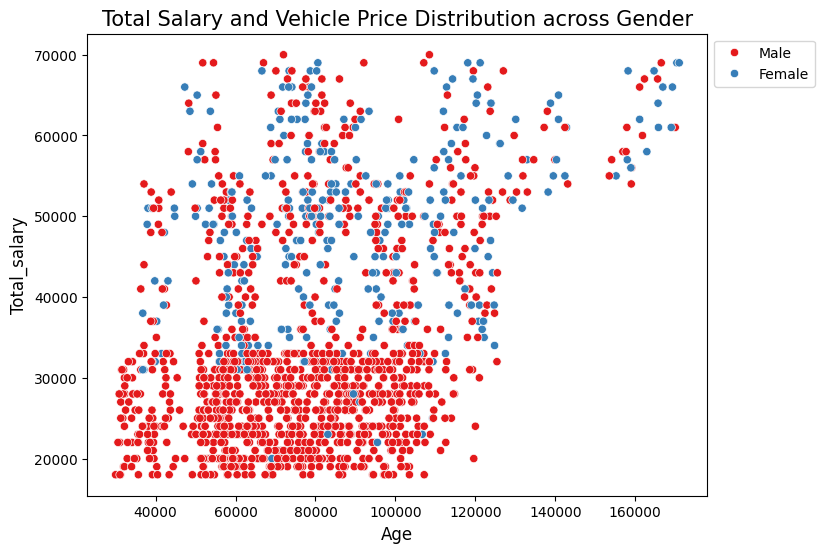

In [116]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x='Total_salary', y= 'Price', hue= 'Gender', palette='Set1')
plt.title('Total Salary and Vehicle Price Distribution across Gender', fontsize=15)
plt.xlabel('Age', fontsize= 12)
plt.ylabel('Total_salary', fontsize= 12)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

### **Age and Make Influence on Vehicle Price**

**Observation**: The scatter plot visualizes the relationship between age and vehicle price, differentiated by vehicle make.

**Insight**: Different vehicle makes may be more popular among different age groups, with certain makes being preferred by older or younger individuals.

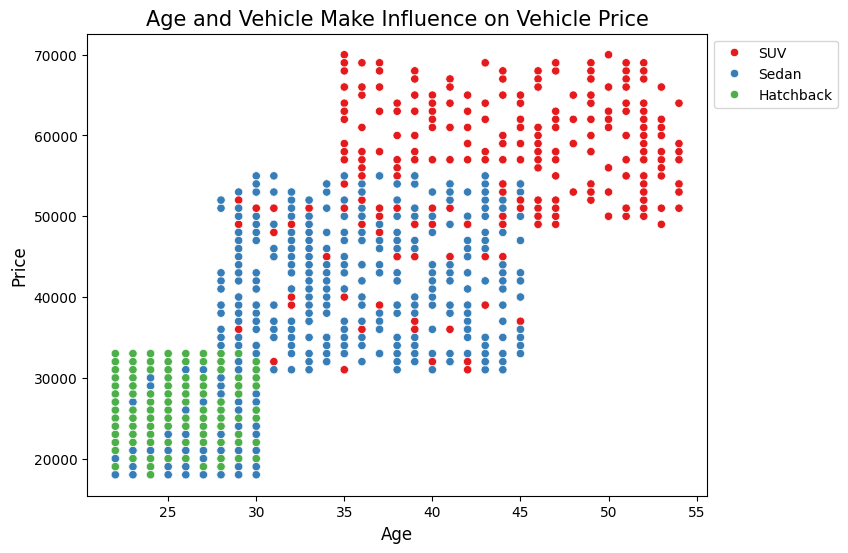

In [118]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x='Age', y= 'Price', hue= 'Make', palette='Set1')
plt.title('Age and Vehicle Make Influence on Vehicle Price', fontsize=15)
plt.xlabel('Age', fontsize= 12)
plt.ylabel('Price', fontsize= 12)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

### **Age and Total Salary Distribution by Profession**

**Observation**: The scatter plot shows the relationship between age and total salary, differentiated by profession.

**Insight**: There are profession-based differences in the relationship between age and total salary, with certain professions having higher total salaries at similar ages.

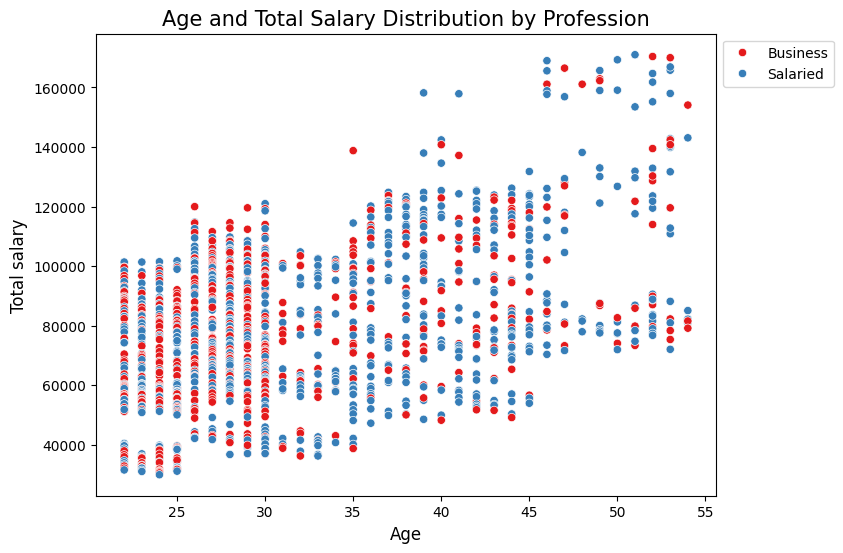

In [120]:
plt.figure(figsize=(8,6))
sns.scatterplot(data= df, x='Age', y= 'Total_salary', hue='Profession', palette='Set1')
plt.title('Age and Total Salary Distribution by Profession', fontsize=15)
plt.xlabel('Age', fontsize= 12)
plt.ylabel('Total salary', fontsize= 12)
plt.legend(bbox_to_anchor=(1, 1))
plt.show()

# Key Questions and Answers

In [122]:
df.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700,170000,61000,SUV
1,53,Female,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200,139900,57000,SUV


#### **1. Do men tend to prefer SUVs more compared to women?**

In [124]:
a = df.loc[df['Make'] == 'SUV', 'Gender'].value_counts(normalize= True)*100
print(a)

Gender
Female    58.249158
Male      41.750842
Name: proportion, dtype: float64


**Observation**: The proportion of SUV purchases by gender is as follows:
- Female: 58.24%
- Male: 41.80%
  
**Insight**: Women tend to prefer SUVs more compared to men, as a higher percentage of SUV purchases are made by females.


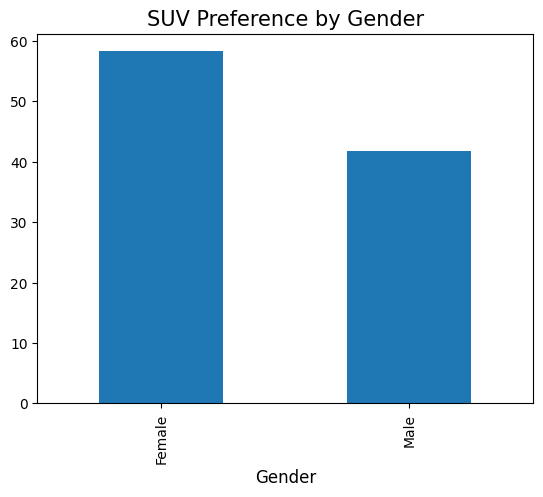

In [126]:
a.plot(kind= 'bar')
plt.title('SUV Preference by Gender', fontsize= 15)
plt.xlabel('Gender', fontsize= 12)
plt.savefig('SUV Preference by Gender.png')
plt.show()

#### **2. What is the likelihood of a salaried person buying a Sedan?**

In [128]:
b = df.loc[(df['Profession'] == 'Salaried'),'Make'].value_counts(normalize= True)*100
print(b)

Make
Sedan        44.196429
Hatchback    32.589286
SUV          23.214286
Name: proportion, dtype: float64


**Observation**: The likelihood of a salaried person buying a Sedan is 44.20%.

**Insight**: Approximately 44.20% of salaried individuals prefer to buy Sedans.


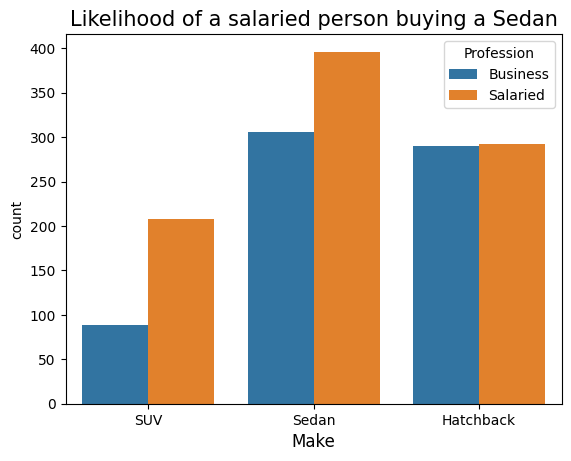

In [130]:
sns.countplot(data=df, x= 'Make', hue='Profession')
plt.title('Likelihood of a salaried person buying a Sedan', fontsize= 15)
plt.xlabel('Make', fontsize= 12)
plt.savefig('Likelihood of a salaried person buying a Sedan.png')
plt.show()

#### **3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?**

In [132]:
c =  df.loc[(df['Profession'] == 'Salaried') & (df['Gender'] == 'Male'), 'Make'].value_counts(normalize= True)*100
print(c)

Make
Sedan        45.386905
Hatchback    41.220238
SUV          13.392857
Name: proportion, dtype: float64


**Observation**: The distribution of vehicle purchases by salaried males is as follows:
- Sedan: 45.40%
- Hatchback: 41.22%
- SUV: 13.40%

**Insight**: The data does not support Sheldon Cooper's claim. Salaried males are more likely to buy Sedans and Hatchbacks compared to SUVs.

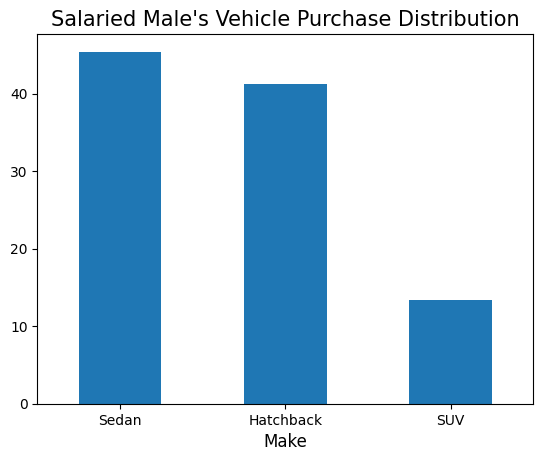

In [134]:
c.plot(kind='bar')
plt.title("Salaried Male's Vehicle Purchase Distribution", fontsize= 15)
plt.xlabel('Make', fontsize= 12)
plt.savefig("Salaried Male's Vehicle Purchase Distribution.png")
plt.xticks(rotation= 360)
plt.show()

#### **4. How does the the amount spent on purchasing automobiles vary by gender?**

In [136]:
d = df.groupby(['Gender'])[['Price']].sum()
print(d)

           Price
Gender          
Female  15695000
Male    40585000


**Observation**: The total amount spent on purchasing automobiles by gender is as follows:
- Female: 15,695,000
- Male: 40,585,000


**Insight**: Males spend significantly more on purchasing automobiles compared to females.


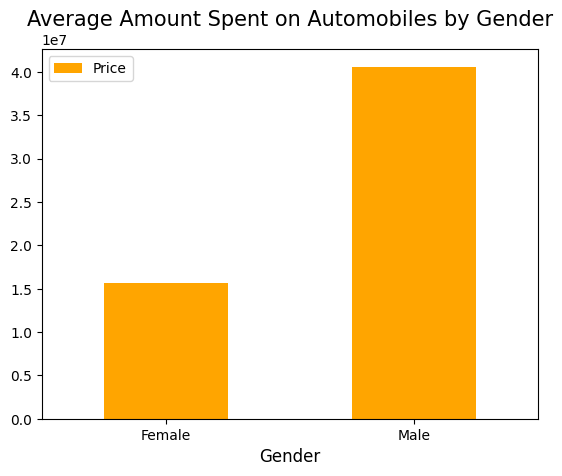

In [138]:
d.plot(kind='bar', color='orange')
plt.title('Average Amount Spent on Automobiles by Gender', fontsize= 15)
plt.xlabel('Gender', fontsize= 12)
plt.xticks(rotation= 360)
plt.savefig('Average Amount Spent on Automobiles by Gender.png')
plt.show()

#### **5. How much money was spent on purchasing automobiles by individuals who took a personal loan?**

In [140]:
e = df.groupby('Personal_loan')[['Price']].sum()
print(e)

                  Price
Personal_loan          
No             28990000
Yes            27290000


**Observation**: The total amount spent by individuals who took a personal loan is 27,290,000.

**Insight**: A substantial amount of money (27,290,000) was spent on purchasing automobiles by individuals who took a personal loan.

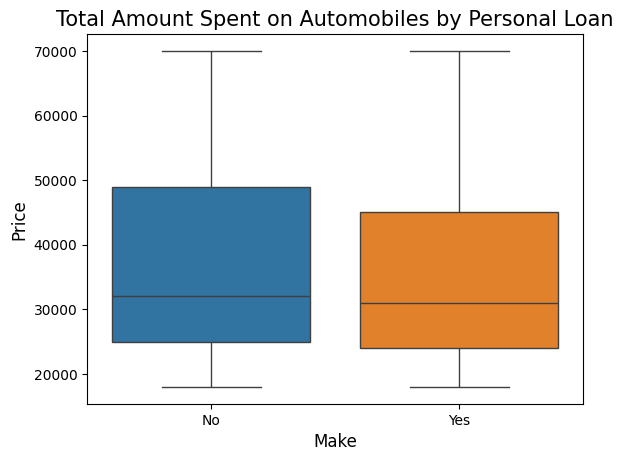

In [142]:
sns.boxplot(data=df, x='Personal_loan', y='Price',hue='Personal_loan')
plt.title("Total Amount Spent on Automobiles by Personal Loan", fontsize= 15)
plt.xlabel('Make', fontsize= 12)
plt.ylabel('Price', fontsize= 12)
plt.savefig("Total Amount Spent on Automobiles by Personal Loan.png")
plt.show()

#### **6. How does having a working partner influence the purchase of higher-priced cars?**

In [144]:
f = df.groupby('Partner_working')[['Price']].mean()
print(f)

                        Price
Partner_working              
No               36000.000000
Yes              35267.281106


**Observation**: The average price of cars purchased is as follows:
- With working partner: 35,267.28
- Without working partner: 36,000.00

**Insight**: Having a working partner does not significantly influence the purchase of higher-priced cars, as the average prices are relatively close.

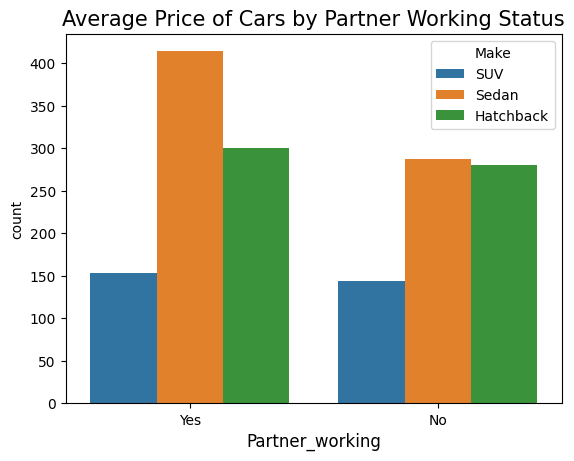

In [146]:
sns.countplot(data=df, x='Partner_working', hue='Make')
plt.title('Average Price of Cars by Partner Working Status', fontsize = 15)
plt.xlabel('Partner_working', fontsize= 12)
plt.savefig('Average Price of Cars by Partner Working Status.png')
plt.show()

# Actionable Insights

1. Women tend to prefer SUVs more compared to men.
2. Nearly half of the salaried individuals prefer Sedans.
3. Salaried males are more likely to buy Sedans or Hatchbacks over SUVs.
4. Males tend to spend more on automobiles compared to females.
5. A significant amount of money was spent by individuals who took personal loans.
6. Having a working partner does not significantly influence the purchase of higher-priced cars.

# Business Recommendations

1. Focus marketing efforts on men for SUVs.
2. Offer special promotions for Sedans to salaried individuals.
3. Focus on promoting Sedans and Hatchbacks to salaried males.
4. Develop premium vehicle models targeting female customers.
5. Provide attractive financing options for individuals taking personal loans.
6. Organize exclusive events or promotions for families with two incomes.